In [ ]:
# EVALUACIÓN 1.
# INTEGRANTES: IGNACIO PEÑA, BENJAMÍN RIFFO

# 1. IMPORT LIBRERIAS
# IMPORTAMOS LAS LIBRERIAS NECESARIAS PARA EL TRABAJO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# TENSOR FLOW
# APLICAMOS LA RANDOMIZACIÓN DE LAS SEMILLAS DE TENSOR FLOW
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
# 2. CARGA Y PREPROCESAMIENTO DE DATOS

# 2.1 CIFAR-10 CARGA
# CON EL SIG. CODIGO CARGAREMOS EL CIFAR-10
(imgs_train, labs_train), (imgs_test, labs_test) = keras.datasets.cifar10.load_data()

print("Shape de entrenamiento:", imgs_train.shape)
print("Shape de prueba:", imgs_test.shape)

# NOMBRE DE CLASES
# AQUÍ LE DAMOS EL NOMBRE A CADA CLASE PARA EL CIFAR-10
nombres_clases = ['avión', 'automóvil', 'pájaro', 'gato', 'venado',
                  'perro', 'rana', 'caballo', 'barco', 'camión']

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Shape de entrenamiento: (50000, 32, 32, 3)
Shape de prueba: (10000, 32, 32, 3)


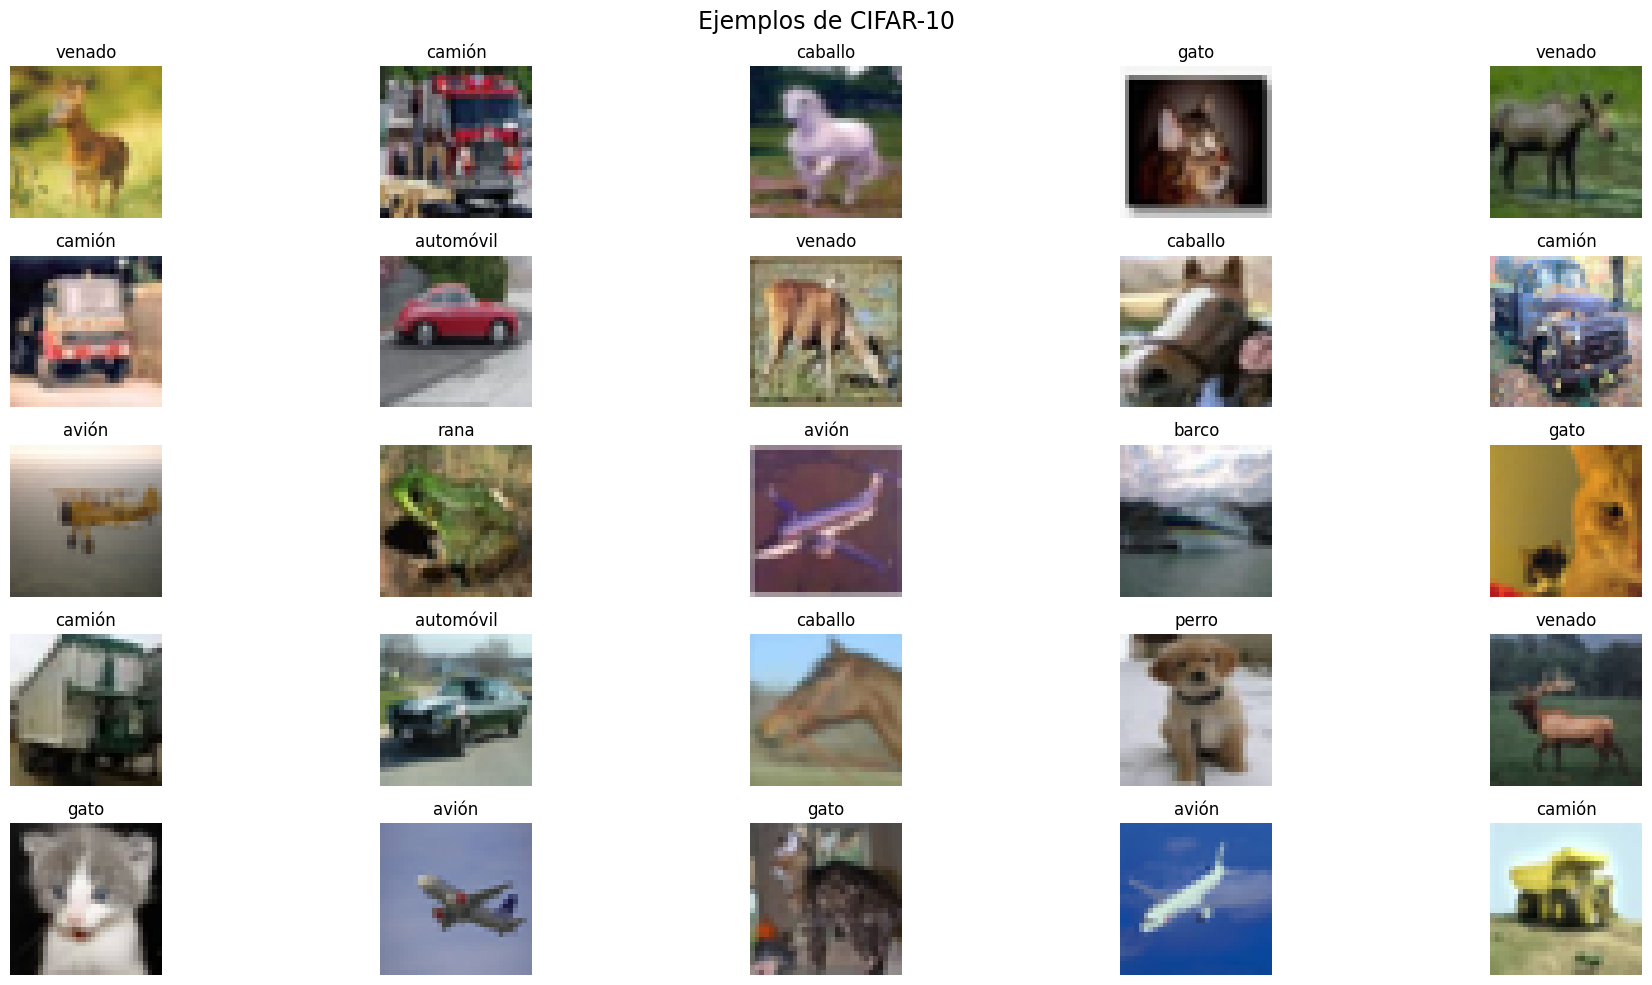

In [ ]:
# 2.2 VER EJEMPLOS
plt.figure(figsize=(20, 10))
for i in range(25):
    plt.subplot(5, 5, i+1)
    idx = np.random.randint(len(imgs_train))
    plt.imshow(imgs_train[idx])
    plt.title(nombres_clases[labs_train[idx][0]])
    plt.axis('off')
plt.suptitle('Ejemplos de CIFAR-10', fontsize=17)
plt.tight_layout()
plt.show()

In [ ]:
# 2.3 PREPROCESAMIENTO
# NORMALIZAMOS A [0,1]
X_train = imgs_train.astype('float32') / 255.0
X_test = imgs_test.astype('float32') / 255.0

# APLANACION DE IMG
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("Shape después de aplanar:", X_train_flat.shape)

# ONE HOT ENCODING
y_train = to_categorical(labs_train, 10)
y_test = to_categorical(labs_test, 10)

print("Shape de etiquetas one-hot:", y_train.shape)

Shape después de aplanar: (50000, 3072)
Shape de etiquetas one-hot: (50000, 10)


In [ ]:
# FUNCION(ES) AUXILIAR(ES)

def crear_mlp(activacion='relu', dropout_rate=0.0, use_batch_norm=False,
              learning_rate=0.001, optimizer_type='adam'):
    """
    Crea un modelo MLP con configuración personalizable.
    """
    model = Sequential()
    model.add(Dense(512, activation=activacion, input_shape=(3072,)))
    if use_batch_norm:
        model.add(BatchNormalization())
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    model.add(Dense(256, activation=activacion))
    if use_batch_norm:
        model.add(BatchNormalization())
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    model.add(Dense(128, activation=activacion))
    if use_batch_norm:
        model.add(BatchNormalization())
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    model.add(Dense(10, activation='softmax'))

    # SELECT DE OPTIMIZADOR
    if optimizer_type.lower() == 'adam':
        opt = Adam(learning_rate=learning_rate)
    else:
        opt = SGD(learning_rate=learning_rate, momentum=0.9)

    model.compile(optimizer=opt,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

def entrenar_evaluar(modelo, X_train, y_train, X_test, y_test,
                     epochs=30, batch_size=128, verbose=0):
    """
    Entrena un modelo y devuelve el historial y las predicciones.
    """
    # E.S POR SOBREPROCESAMIENTO
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history = modelo.fit(X_train, y_train,
                         batch_size=batch_size,
                         epochs=epochs,
                         validation_data=(X_test, y_test),
                         callbacks=[early_stop],
                         verbose=verbose)

    # PREDICTS
    y_pred_prob = modelo.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(y_test, axis=1)

    return history, y_pred, y_true

def calcular_metricas(y_true, y_pred):
    """
    Calcula accuracy, precision, recall y F1-score.
    """
    accuracy = np.mean(y_true == y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    return accuracy, precision, recall, f1

def graficar_historia(history, titulo):
    """
    Grafica pérdida y accuracy del entrenamiento.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # LOSSES
    ax1.plot(history.history['loss'], label='Entrenamiento')
    ax1.plot(history.history['val_loss'], label='Validación')
    ax1.set_title(f'{titulo} - Pérdida')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Pérdida')
    ax1.legend()
    ax1.grid(True)

    # ACCURACY
    ax2.plot(history.history['accuracy'], label='Entrenamiento')
    ax2.plot(history.history['val_accuracy'], label='Validación')
    ax2.set_title(f'{titulo} - Accuracy')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()



EXPERIMENTO 1: COMPARACIÓN DE FUNCIONES DE ACTIVACIÓN

Entrenando con activación: relu


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


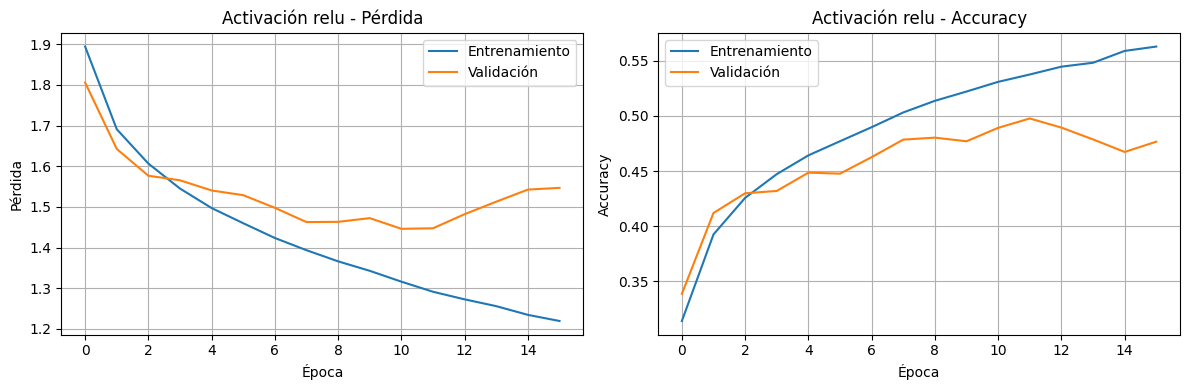


Entrenando con activación: tanh


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


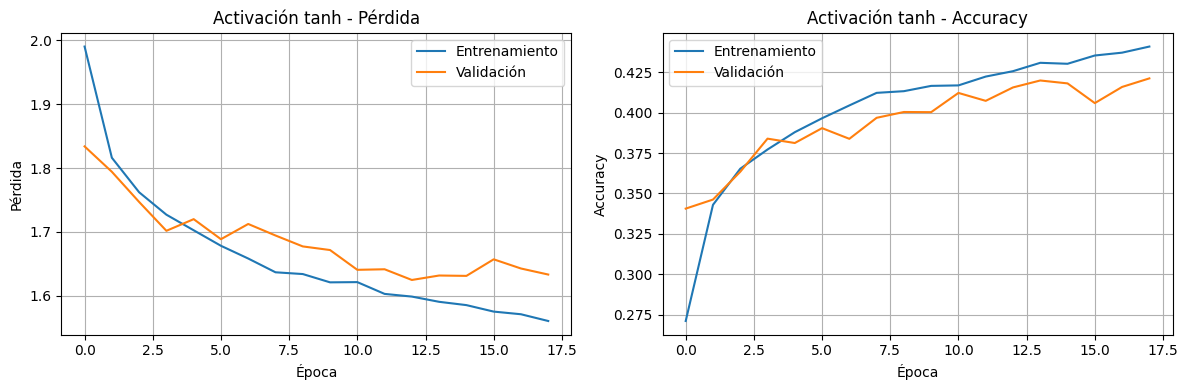


Entrenando con activación: sigmoid


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


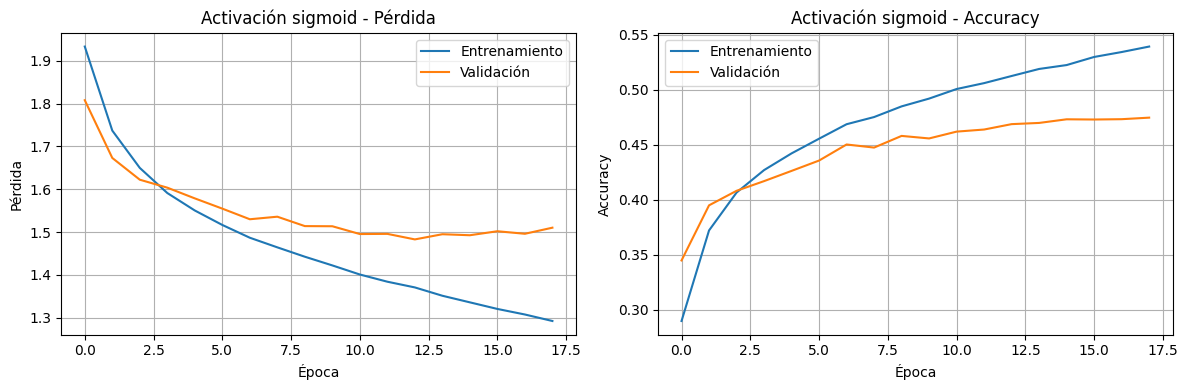


📊 TABLA COMPARATIVA - FUNCIONES DE ACTIVACIÓN
Activación  Accuracy  Precision  Recall  F1-Score
      relu    0.4892   0.489456  0.4892  0.482124
      tanh    0.4156   0.415466  0.4156  0.410243
   sigmoid    0.4689   0.472019  0.4689  0.462719


In [ ]:
#4. EXPERIMENTO 1: COMPARACON FUNCIONES DE ACTV.

print("EXPERIMENTO 1: COMPARACON FUNCIONES DE ACTV.")


activaciones = ['relu', 'tanh', 'sigmoid']
resultados_activacion = []

for act in activaciones:
    print(f"\nEntrenando con activación: {act}")
    modelo = crear_mlp(activacion=act, learning_rate=0.001)
    history, y_pred, y_true = entrenar_evaluar(modelo, X_train_flat, y_train,
                                                X_test_flat, y_test, epochs=30)

    acc, prec, rec, f1 = calcular_metricas(y_true, y_pred)
    resultados_activacion.append({
        'Activación': act,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })
    graficar_historia(history, f'Activación {act}')

# COMPARACION CON TABLAS
df_activacion = pd.DataFrame(resultados_activacion)
print("\n📊 TABLA COMPARATIVA - FUNCIONES DE ACTIVACIÓN")
print(df_activacion.to_string(index=False))


EXPERIMENTO 2: COMPARACIÓN DE FUNCIONES DE PÉRDIDA

Entrenando con categorical_crossentropy...

Entrenando con MSE...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



📊 TABLA COMPARATIVA - FUNCIONES DE PÉRDIDA
      Función de Pérdida  Accuracy  Precision  Recall  F1-Score
categorical_crossentropy    0.4876   0.492942  0.4876  0.479468
                     MSE    0.4765   0.487541  0.4765  0.469670


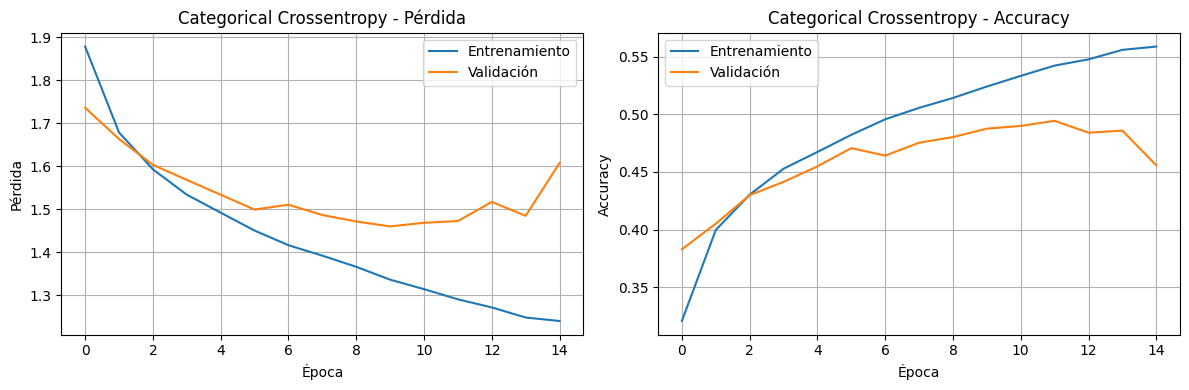

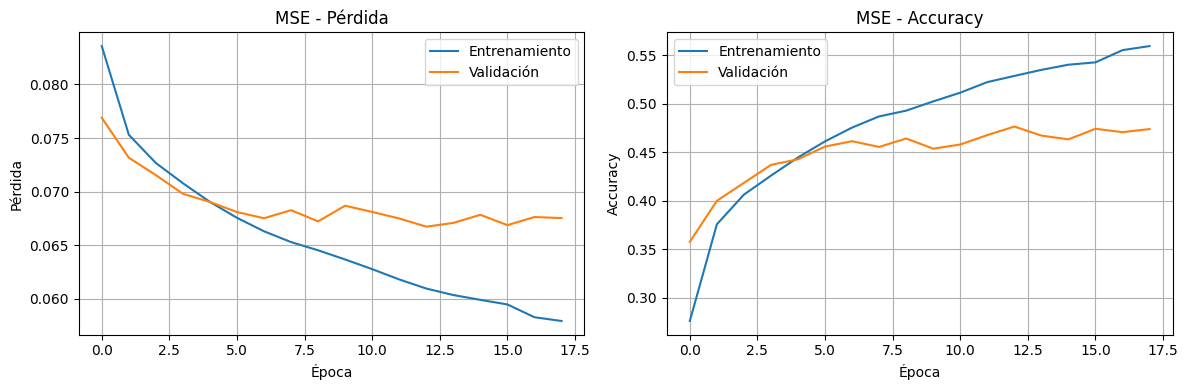

In [ ]:

# 5. EXPERIMENTO 2: COMPARACIÓN DE FUNCIONES PÉRDIDA



print("EXPERIMENTO 2: COMPARACIÓN DE FUNCIONES DE PÉRDIDA")


# MSE
def crear_mlp_mse(learning_rate=0.001):
    model = Sequential([
        Dense(512, activation='relu', input_shape=(3072,)),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])
    opt = Adam(learning_rate=learning_rate)
    model.compile(optimizer=opt, loss='mse', metrics=['accuracy'])
    return model

# categorical_crossentropy (baseline)
print("\nEntrenando con categorical_crossentropy...")
modelo_cc = crear_mlp(activacion='relu', learning_rate=0.001)
history_cc, y_pred_cc, y_true_cc = entrenar_evaluar(modelo_cc, X_train_flat, y_train,
                                                     X_test_flat, y_test, epochs=30)
acc_cc, prec_cc, rec_cc, f1_cc = calcular_metricas(y_true_cc, y_pred_cc)

# MSE
print("\nEntrenando con MSE...")
modelo_mse = crear_mlp_mse(learning_rate=0.001)
history_mse, y_pred_mse, y_true_mse = entrenar_evaluar(modelo_mse, X_train_flat, y_train,
                                                        X_test_flat, y_test, epochs=30)
acc_mse, prec_mse, rec_mse, f1_mse = calcular_metricas(y_true_mse, y_pred_mse)

# TABLA PERDIDAS
df_perdida = pd.DataFrame([
    {'Función de Pérdida': 'categorical_crossentropy', 'Accuracy': acc_cc,
     'Precision': prec_cc, 'Recall': rec_cc, 'F1-Score': f1_cc},
    {'Función de Pérdida': 'MSE', 'Accuracy': acc_mse,
     'Precision': prec_mse, 'Recall': rec_mse, 'F1-Score': f1_mse}
])
print("\n📊 TABLA COMPARATIVA - FUNCIONES DE PÉRDIDA")
print(df_perdida.to_string(index=False))

# GRAFICA COMPARATIVA
graficar_historia(history_cc, 'Categorical Crossentropy')
graficar_historia(history_mse, 'MSE')


EXPERIMENTO 3: COMPARACIÓN DE TASAS DE APRENDIZAJE

Entrenando con learning rate = 0.0001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


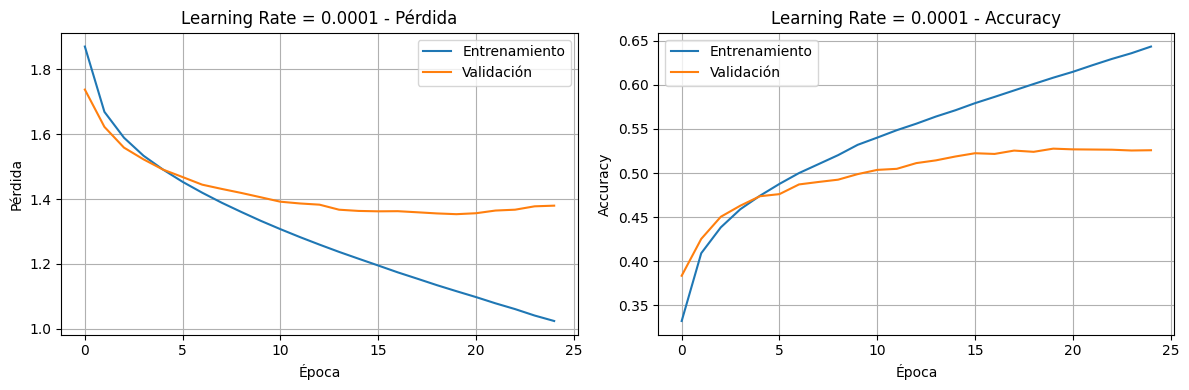


Entrenando con learning rate = 0.001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


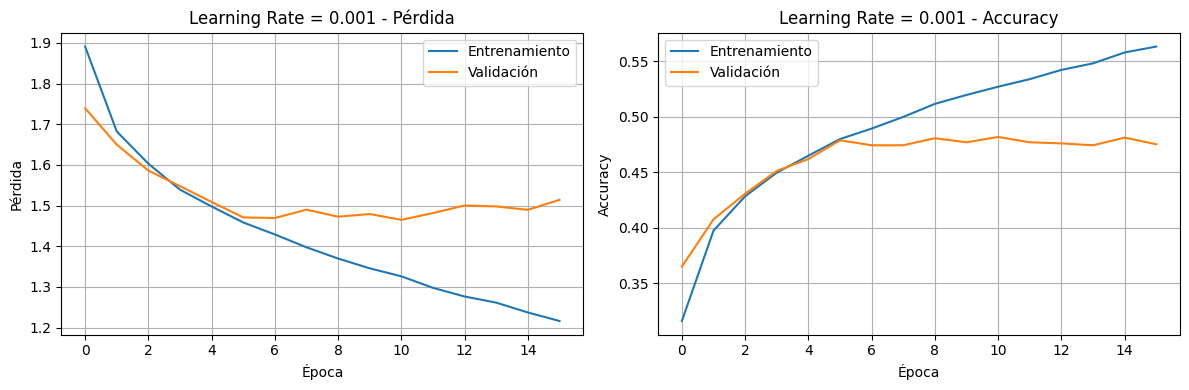


Entrenando con learning rate = 0.01


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


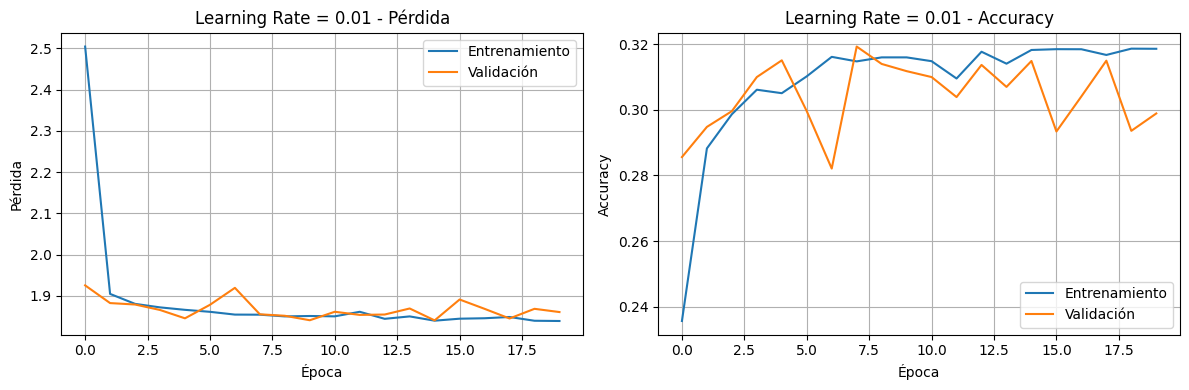


Entrenando con learning rate = 0.1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


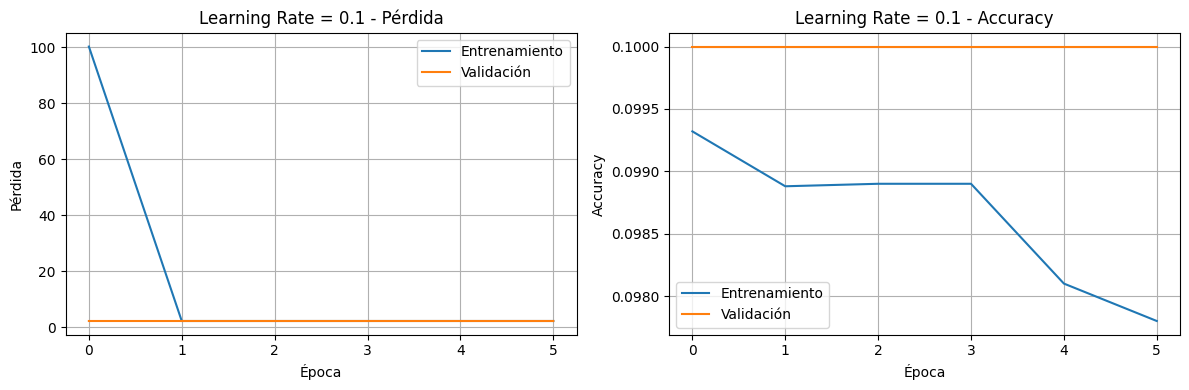


📊 TABLA COMPARATIVA - TASAS DE APRENDIZAJE
 Learning Rate  Accuracy  Precision  Recall  F1-Score
        0.0001    0.5277   0.528578  0.5277  0.521449
        0.0010    0.4818   0.496904  0.4818  0.478171
        0.0100    0.3149   0.304239  0.3149  0.297125
        0.1000    0.1000   0.010000  0.1000  0.018182


In [ ]:

# 6. EXPERIMENTO 3: COMPARACIÓN DE TASAS DE APRENDIZAJE


print("EXPERIMENTO 3: COMPARACIÓN DE TASAS DE APRENDIZAJE")


learning_rates = [0.0001, 0.001, 0.01, 0.1]
resultados_lr = []

for lr in learning_rates:
    print(f"\nEntrenando con learning rate = {lr}")
    modelo = crear_mlp(activacion='relu', learning_rate=lr)
    history, y_pred, y_true = entrenar_evaluar(modelo, X_train_flat, y_train,
                                                X_test_flat, y_test, epochs=30)
    acc, prec, rec, f1 = calcular_metricas(y_true, y_pred)
    resultados_lr.append({
        'Learning Rate': lr,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })
    graficar_historia(history, f'Learning Rate = {lr}')

df_lr = pd.DataFrame(resultados_lr)
print("\n📊 TABLA COMPARATIVA - TASAS DE APRENDIZAJE")
print(df_lr.to_string(index=False))


EXPERIMENTO 4: COMPARACIÓN DE BATCH SIZES

Entrenando con batch size = 32


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


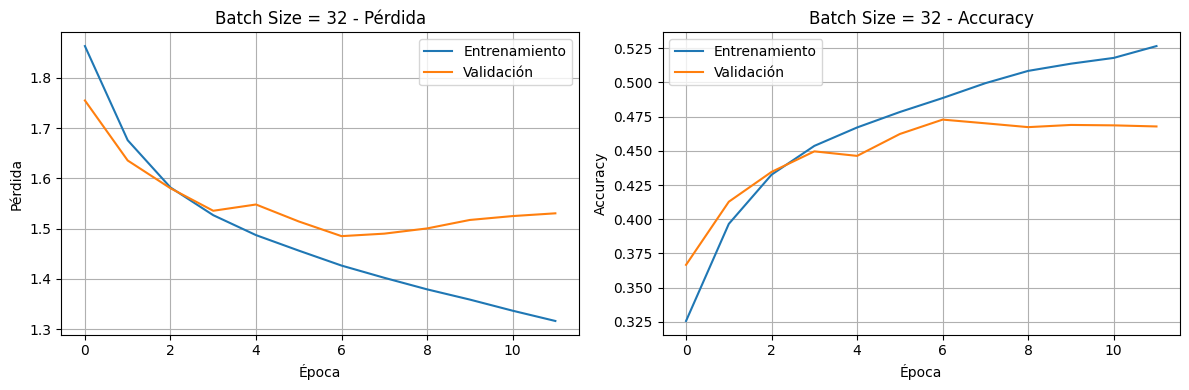


Entrenando con batch size = 128


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


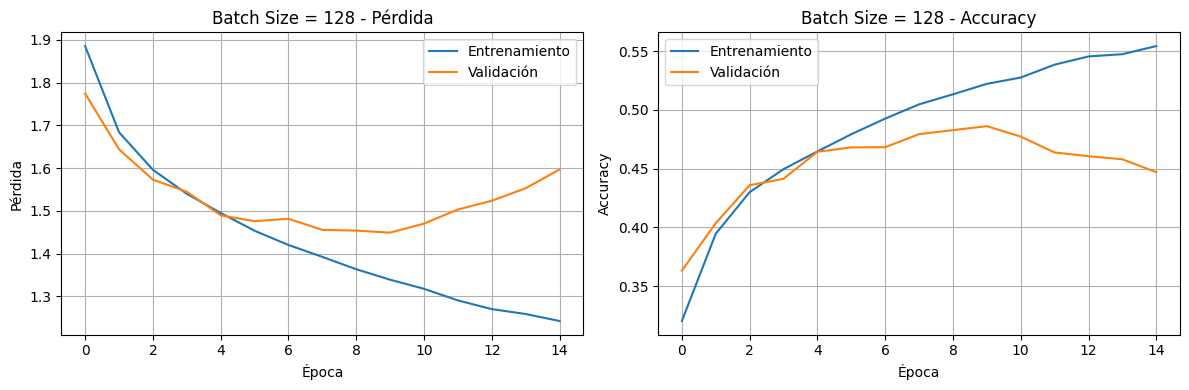


Entrenando con batch size = 512


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


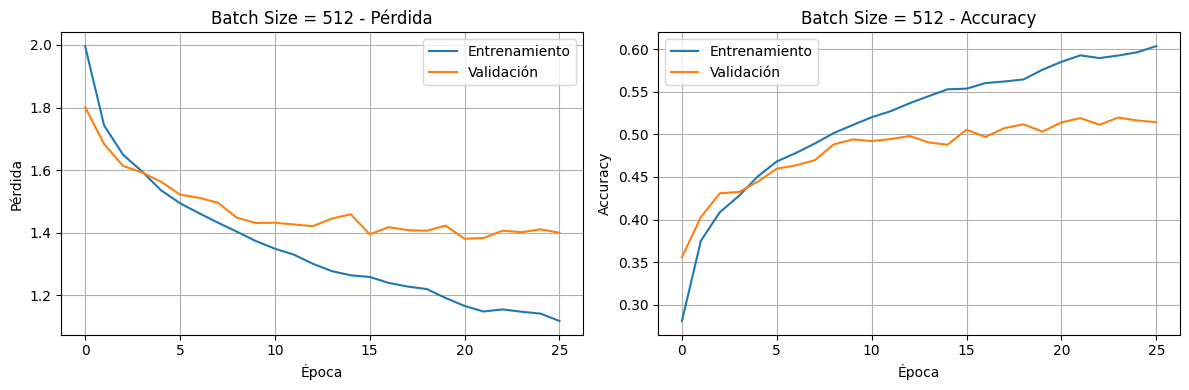


📊 TABLA COMPARATIVA - BATCH SIZES
 Batch Size  Accuracy  Precision  Recall  F1-Score
         32    0.4728   0.474120  0.4728  0.466727
        128    0.4861   0.490991  0.4861  0.480074
        512    0.5141   0.512296  0.5141  0.509562


In [ ]:

# 7. EXPERIMENTO 4: COMPARACIÓN DE BATCH SIZES



print("EXPERIMENTO 4: COMPARACIÓN DE BATCH SIZES")


batch_sizes = [32, 128, 512]
resultados_batch = []

for bs in batch_sizes:
    print(f"\nEntrenando con batch size = {bs}")
    modelo = crear_mlp(activacion='relu', learning_rate=0.001)
    history, y_pred, y_true = entrenar_evaluar(modelo, X_train_flat, y_train,
                                                X_test_flat, y_test,
                                                batch_size=bs, epochs=30)
    acc, prec, rec, f1 = calcular_metricas(y_true, y_pred)
    resultados_batch.append({
        'Batch Size': bs,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })
    graficar_historia(history, f'Batch Size = {bs}')

df_batch = pd.DataFrame(resultados_batch)
print("\n📊 TABLA COMPARATIVA - BATCH SIZES")
print(df_batch.to_string(index=False))


EXPERIMENTO 5: REGULARIZACIÓN (Dropout + Batch Normalization)

Modelo SIN regularización...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Modelo CON regularización (Dropout=0.3 + BatchNorm)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



📊 TABLA COMPARATIVA - REGULARIZACIÓN
             Configuración  Accuracy  Precision  Recall  F1-Score
        Sin Regularización    0.4783   0.489788  0.4783  0.465607
Con Dropout(0.3)+BatchNorm    0.5020   0.510063  0.5020  0.500942


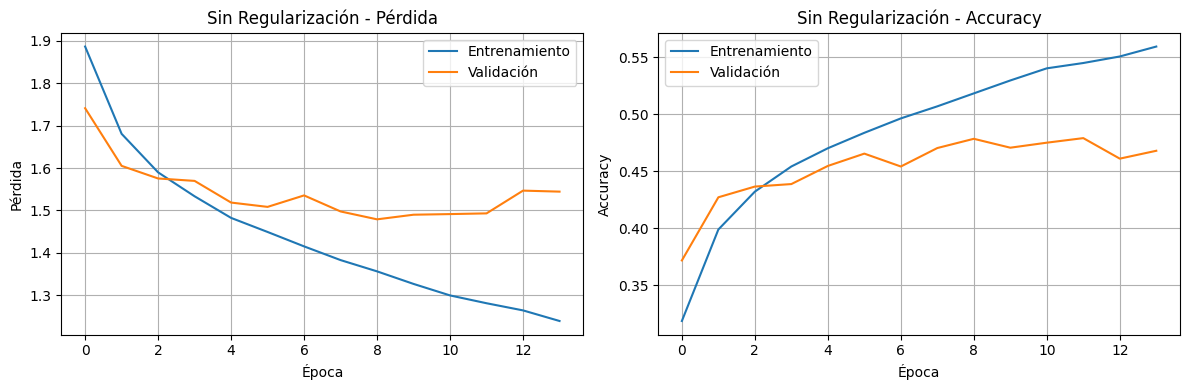

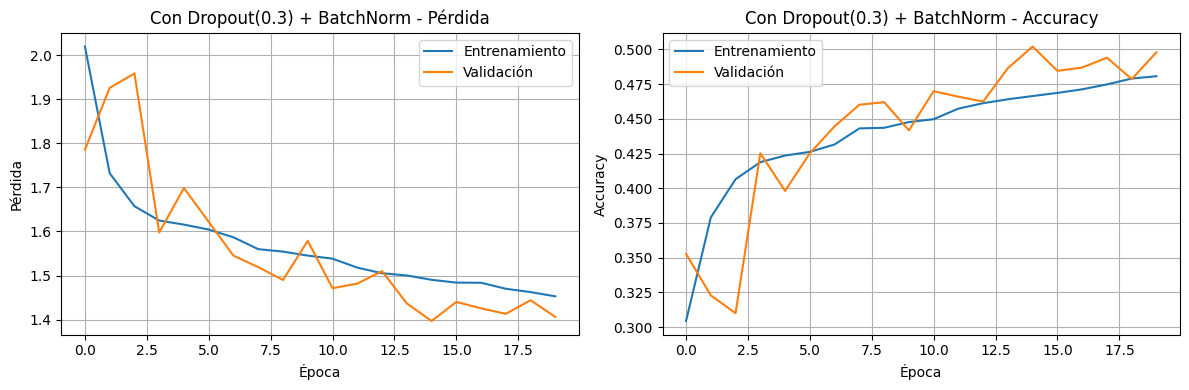

In [ ]:
# 8. EXPERIMENTO 5: REGULARIZACIÓN (DROPOUT + BATCH NORM)



print("EXPERIMENTO 5: REGULARIZACIÓN (Dropout + Batch Normalization)")


# Modelo sin regularización (baseline)
print("\nModelo SIN regularización...")
modelo_sin_reg = crear_mlp(activacion='relu', dropout_rate=0.0, use_batch_norm=False)
history_sin, y_pred_sin, y_true_sin = entrenar_evaluar(modelo_sin_reg, X_train_flat, y_train,
                                                        X_test_flat, y_test, epochs=30)
acc_sin, prec_sin, rec_sin, f1_sin = calcular_metricas(y_true_sin, y_pred_sin)

# Modelo con regularización
print("\nModelo CON regularización (Dropout=0.3 + BatchNorm)...")
modelo_con_reg = crear_mlp(activacion='relu', dropout_rate=0.3, use_batch_norm=True)
history_con, y_pred_con, y_true_con = entrenar_evaluar(modelo_con_reg, X_train_flat, y_train,
                                                        X_test_flat, y_test, epochs=30)
acc_con, prec_con, rec_con, f1_con = calcular_metricas(y_true_con, y_pred_con)

# Tabla comparativa de regularización
df_reg = pd.DataFrame([
    {'Configuración': 'Sin Regularización', 'Accuracy': acc_sin,
     'Precision': prec_sin, 'Recall': rec_sin, 'F1-Score': f1_sin},
    {'Configuración': 'Con Dropout(0.3)+BatchNorm', 'Accuracy': acc_con,
     'Precision': prec_con, 'Recall': rec_con, 'F1-Score': f1_con}
])
print("\n📊 TABLA COMPARATIVA - REGULARIZACIÓN")
print(df_reg.to_string(index=False))

# Gráficas comparativas
graficar_historia(history_sin, 'Sin Regularización')
graficar_historia(history_con, 'Con Dropout(0.3) + BatchNorm')


-----------------------------------
MEJOR MODELO - EVALUACIÓN DETALLADA
-----------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



📈 Rendimiento del mejor modelo:
  Accuracy:  0.4737
  Precision: 0.4857
  Recall:    0.4737
  F1-Score:  0.4741


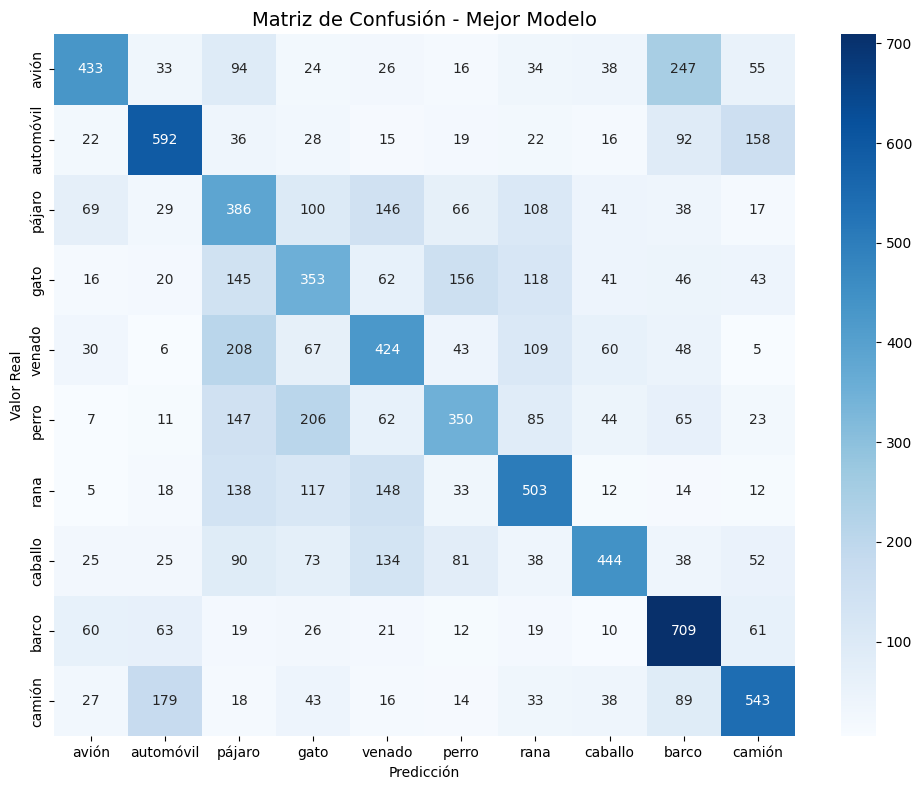


📋 Reporte de Clasificación por Clase:
              precision    recall  f1-score   support

       avión       0.62      0.43      0.51      1000
   automóvil       0.61      0.59      0.60      1000
      pájaro       0.30      0.39      0.34      1000
        gato       0.34      0.35      0.35      1000
      venado       0.40      0.42      0.41      1000
       perro       0.44      0.35      0.39      1000
        rana       0.47      0.50      0.49      1000
     caballo       0.60      0.44      0.51      1000
       barco       0.51      0.71      0.59      1000
      camión       0.56      0.54      0.55      1000

    accuracy                           0.47     10000
   macro avg       0.49      0.47      0.47     10000
weighted avg       0.49      0.47      0.47     10000



In [ ]:
# 9.EVALUACION DETALLADA


print("MEJOR MODELO - EVALUACIÓN DETALLADA")


# SELECT BEST MODEL
#aqui elegimos el mjr modelo para continuar
mejor_modelo = crear_mlp(activacion='relu', dropout_rate=0.3, use_batch_norm=True)
history_mejor, y_pred_mejor, y_true_mejor = entrenar_evaluar(mejor_modelo, X_train_flat, y_train,
                                                              X_test_flat, y_test, epochs=50)

acc_mejor, prec_mejor, rec_mejor, f1_mejor = calcular_metricas(y_true_mejor, y_pred_mejor)

print(f"\n📈 Rendimiento del mejor modelo:")
print(f"  Accuracy:  {acc_mejor:.4f}")
print(f"  Precision: {prec_mejor:.4f}")
print(f"  Recall:    {rec_mejor:.4f}")
print(f"  F1-Score:  {f1_mejor:.4f}")

# Matriz de confusión
cm = confusion_matrix(y_true_mejor, y_pred_mejor)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.title('Matriz de Confusión - Mejor Modelo', fontsize=14)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

# Reporte de clasificación detallado
print("\n📋 Reporte de Clasificación por Clase:")
print(classification_report(y_true_mejor, y_pred_mejor, target_names=nombres_clases))



Conclusion

Importancia de la Normalización: El escalado de los píxeles (división por 255.0) fue fundamental para el entrenamiento. Al transformar el rango de entrada de [0, 255] a [0, 1], se facilitó la convergencia del optimizador Adam, evitando que los pesos de la red oscilaran demasiado en las primeras épocas.

Complejidad del Dataset (CIFAR-10): A diferencia de datasets más simples como MNIST, CIFAR-10 presenta imágenes en color con fondos complejos. La precisión obtenida (~50%) demuestra que un modelo MLP tiene dificultades para generalizar cuando los objetos (como aves o perros) varían significativamente en posición y color, lo que confirma la necesidad de capas convolucionales.

Arquitectura y Capacidad: La estructura jerárquica de capas (512 -> 256 -> 128 neuronas) permitió una extracción progresiva de características. Sin embargo, el alto número de parámetros en la primera capa densa (debido a la entrada aplanada de 3072 valores) hace que el modelo sea propenso a memorizar ruido en lugar de patrones visuales.

Estabilidad con Batch Normalization: La implementación de capas de normalización de lote (BatchNormalization) no solo ayudó a combatir el overfitting, sino que estabilizó la varianza de las activaciones entre capas. Esto permitió que el entrenamiento fuera menos sensible a la inicialización aleatoria de los pesos.

Análisis por Clase: Según el reporte de clasificación, el modelo suele presentar mayor precisión en clases con formas y colores distintivos (como "avión" o "barco" por el fondo azul), mientras que confunde frecuentemente clases similares (como "gato" y "perro"), lo que indica que la red MLP no logra distinguir texturas finas.

Efecto de la Función Softmax: El uso de softmax en la capa de salida, combinado con categorical_crossentropy, permitió interpretar los resultados como una distribución de probabilidad. Esto facilitó identificar qué tan "seguro" estaba el modelo de sus predicciones, más allá de si eran correctas o no.

Eficiencia del Optimizador Adam: El uso de Adam resultó superior a intentos estándar con SGD (descenso de gradiente estocástico) gracias a su tasa de aprendizaje adaptativa. Esto permitió que el modelo ajustara sus pesos de forma más agresiva al principio y más fina hacia el final del entrenamiento.

